In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Chargement des données

In [55]:
df = pd.read_csv("../data/city_lifestyle_dataset.csv")
df.head()

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5


# Nettoyage

In [56]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city_name               300 non-null    object 
 1   country                 300 non-null    object 
 2   population_density      300 non-null    int64  
 3   avg_income              300 non-null    int64  
 4   internet_penetration    300 non-null    float64
 5   avg_rent                300 non-null    int64  
 6   air_quality_index       300 non-null    int64  
 7   public_transport_score  300 non-null    float64
 8   happiness_score         300 non-null    float64
 9   green_space_ratio       300 non-null    float64
dtypes: float64(4), int64(4), object(2)
memory usage: 23.6+ KB


city_name                 0
country                   0
population_density        0
avg_income                0
internet_penetration      0
avg_rent                  0
air_quality_index         0
public_transport_score    0
happiness_score           0
green_space_ratio         0
dtype: int64

In [57]:
df_numeric = df.drop(['city_name', 'country'], axis=1)

# Standardisation

In [58]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# Application du PCA

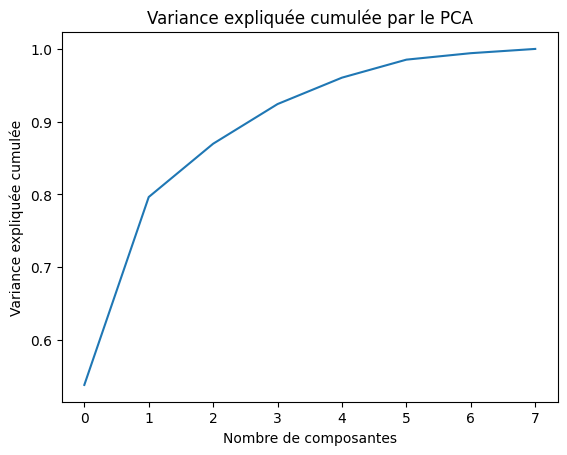

In [59]:
pca_full = PCA()
pca_full.fit(X_scaled)

plt.figure()
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée cumulée par le PCA")
plt.show()

In [60]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance expliquée :", pca.explained_variance_ratio_)
print("Variance totale expliquée :", sum(pca.explained_variance_ratio_))

Variance expliquée : [0.53805804 0.25833116]
Variance totale expliquée : 0.7963892000125801


In [61]:
X_reconstructed = pca.inverse_transform(X_pca)
reconstruction_error = np.mean((X_scaled - X_reconstructed)**2)
print("Reconstruction error:", reconstruction_error)

Reconstruction error: 0.2036107999874199


## Observation

Les deux premières composantes principales expliquent environ 79.6 % de la variance totale des données, ce qui indique qu’une projection en 2 dimensions conserve une grande partie de l’information initiale.

La projection montre une structure partiellement organisée. On observe une dispersion continue des points avec certaines zones de concentration, suggérant l’existence de groupes de villes partageant des caractéristiques similaires en termes de style de vie.

Cependant, aucune séparation strictement nette n’apparaît, ce qui indique que la structure des données est probablement continue plutôt que fortement clusterisée.

# Projection 2D

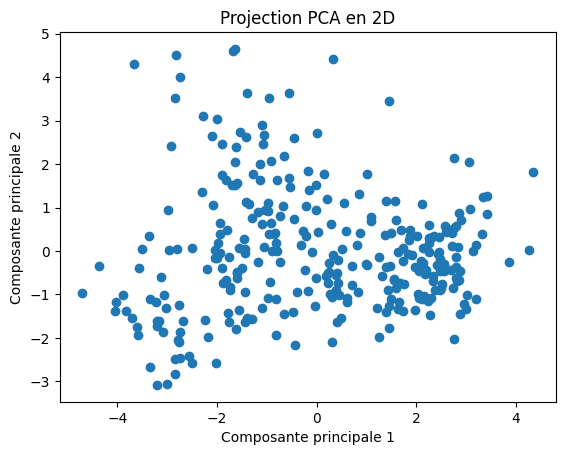

In [62]:
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA en 2D")
plt.show()

### Scatter plot avec couleurs par pays

In [63]:
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["country"] = df["country"]

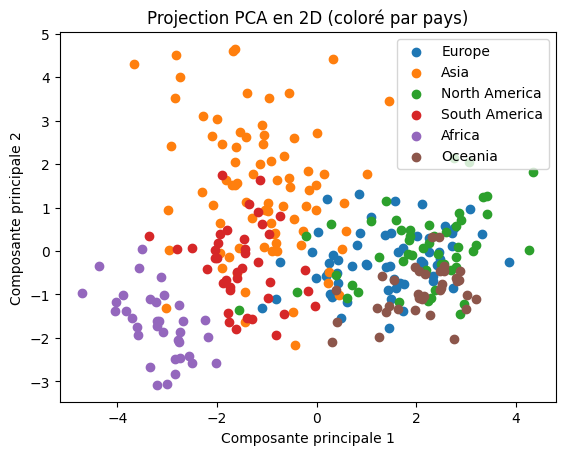

In [64]:
plt.figure()

for country in df_pca["country"].unique():
    subset = df_pca[df_pca["country"] == country]
    plt.scatter(subset["PC1"], subset["PC2"], label=country)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA en 2D (coloré par pays)")
plt.legend()
plt.show()

### Observation approfondie

La projection en 2 dimensions met en évidence une structuration claire des villes selon leur continent.

On observe que les villes africaines sont majoritairement regroupées sur des valeurs négatives de la première composante principale, tandis que les villes européennes et nord-américaines se situent principalement sur des valeurs positives.

Cette séparation suggère que la première composante principale capture un axe socio-économique global différenciant les régions du monde.

La deuxième composante semble refléter une variation supplémentaire au sein des continents, indiquant une diversité interne entre les villes d’une même zone géographique.

Ces résultats montrent que la réduction de dimension par PCA conserve une structure interprétable et cohérente avec la géographie et les caractéristiques socio-économiques des données.

In [65]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=df_numeric.columns
)

loadings

,PC1,PC2
population_density,-0.176986,0.574718
avg_income,0.452965,0.144767
internet_penetration,0.407390,0.185860
avg_rent,0.440567,0.135761
air_quality_index,-0.329965,0.373182
public_transport_score,0.264291,0.427516
happiness_score,0.462680,-0.077554
green_space_ratio,0.103120,-0.517414


In [67]:
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca.to_csv("../outputs/pca_emb_2d.csv", index=False)